Found 2 files in ../results/RQ2Models
            model  ext  nodes  edges    time         mem metamodel source_file
0      result0_10  xmi      2      1   0.518   34.722656      abnf   run_1.csv
1     result0_100  xmi     10      9   0.087   24.000000      abnf   run_1.csv
2    result0_1000  xmi     11     10   0.062   15.662109      abnf   run_1.csv
3   result0_10000  xmi      1      0   0.205   15.175781      abnf   run_1.csv
4  result0_100000  xmi  99151  99150  19.797  272.082031      abnf   run_1.csv


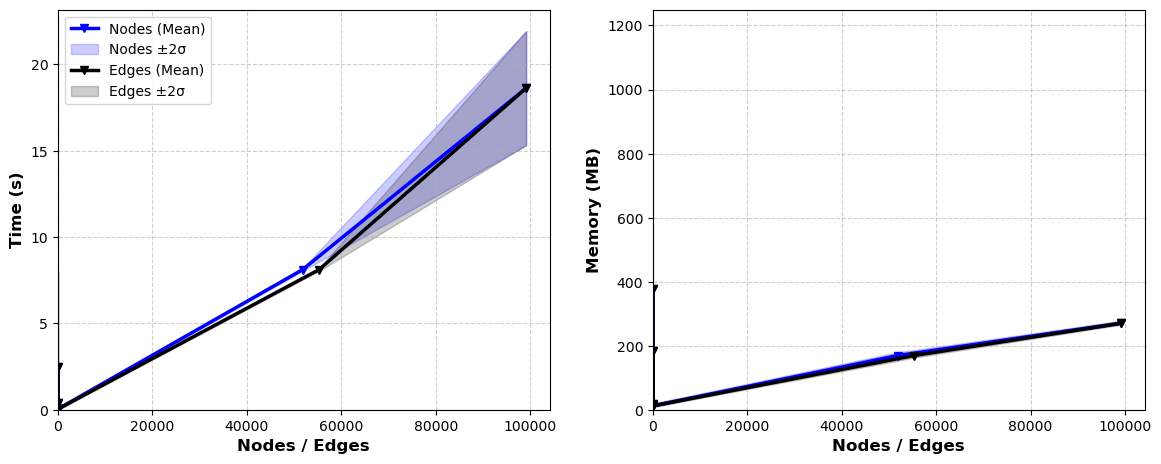

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import glob
import os
import numpy as np


# Helper function to remove outliers
def remove_outliers(series, z_thresh=2.0):
    """Remove outliers based on z-score threshold."""
    mean = series.mean()
    std = series.std()
    z_scores = (series - mean) / std
    return series[np.abs(z_scores) <= z_thresh]


# Root folder (UPDATED)
folders = ["../results/RQ2Models"]

all_data = []

for folder in folders:
    # Recursive search for all CSV files
    files = glob.glob(os.path.join(folder, "**", "*.csv"), recursive=True)
    print(f"Found {len(files)} files in {folder}")

    for file in files:
        df = pd.read_csv(file)

        # Optional but useful: extract metamodel name
        metamodel_name = os.path.basename(os.path.dirname(file))
        df['metamodel'] = metamodel_name

        df['source_file'] = os.path.basename(file)
        df['time'] = df['time'] / 1000.0          # ms → seconds
        df['mem'] = df['mem'] / 1024  # KB → MB
        all_data.append(df)

# Combine into a single DataFrame
combined_df = pd.concat(all_data, ignore_index=True)
print(combined_df.head())


# Plotting
props = ['nodes', 'edges']
colors = {'nodes': 'blue', 'edges': 'black'}
g = 2  # number of std deviations for shaded area

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# TIME
for prop in props:
    grouped = combined_df.groupby(prop)['time']
    mean = grouped.apply(lambda s: remove_outliers(s).mean())
    std = grouped.apply(lambda s: remove_outliers(s).std())
    lower = mean - g * std
    upper = mean + g * std

    axes[0].plot(mean.index, mean.values,
                 color=colors[prop], linewidth=2.5, marker='v',
                 label=f'{prop.capitalize()} (Mean)')
    axes[0].fill_between(mean.index, lower, upper,
                         color=colors[prop], alpha=0.2,
                         label=f'{prop.capitalize()} ±{g}σ')

axes[0].set_xlabel("Nodes / Edges", fontsize=12, fontweight='bold')
axes[0].set_ylabel("Time (s)", fontsize=12, fontweight='bold')
axes[0].grid(True, linestyle='--', alpha=0.6)
axes[0].set_ylim(bottom=0)
axes[0].set_xlim(left=0)
axes[0].legend(fontsize=10, frameon=True)

# MEMORY
for prop in props:
    grouped = combined_df.groupby(prop)['mem']
    mean = grouped.apply(lambda s: remove_outliers(s).mean())
    std = grouped.apply(lambda s: remove_outliers(s).std())
    lower = mean - g * std
    upper = mean + g * std

    axes[1].plot(mean.index, mean.values,
                 color=colors[prop], linewidth=2.5, marker='v',
                 label=f'{prop.capitalize()} (Mean)')
    axes[1].fill_between(mean.index, lower, upper,
                         color=colors[prop], alpha=0.2,
                         label=f'{prop.capitalize()} ±{g}σ')

axes[1].set_xlabel("Nodes / Edges", fontsize=12, fontweight='bold')
axes[1].set_ylabel("Memory (MB)", fontsize=12, fontweight='bold')
axes[1].grid(True, linestyle='--', alpha=0.6)
axes[1].set_ylim(bottom=0)
axes[1].set_xlim(left=0)  

plt.tight_layout(pad=2)
plt.show()

In [4]:
import pandas as pd
import glob
import os
import numpy as np


# Optional: remove outliers

def remove_outliers(series, z_thresh=2.0):
    """Remove outliers based on z-score threshold."""
    mean = series.mean()
    std = series.std()
    z_scores = (series - mean) / std
    return series[np.abs(z_scores) <= z_thresh]


# Load all CSV files

folders = ["../results/RQ2LinTra/java", "../results/RQ2LinTra/movies", "../results/RQ2LinTra/DBLP"]
all_data = []

for folder in folders:
    files = glob.glob(os.path.join(folder, "*.csv"))
    print(f"Found {len(files)} files in {folder}")
    for file in files:
        df = pd.read_csv(file)
        df['folder'] = folder
        all_data.append(df)

# Combine all runs into a single DataFrame
combined_df = pd.concat(all_data, ignore_index=True)


# Compute summary statistics per model

summary = combined_df.groupby('model').agg(
    time_avg=('time', lambda s: remove_outliers(s).mean()),
    time_std=('time', lambda s: remove_outliers(s).std()),
    time_min=('time', lambda s: remove_outliers(s).min()),
    time_max=('time', lambda s: remove_outliers(s).max()),
    mem_avg=('mem', lambda s: remove_outliers(s).mean()),
    mem_std=('mem', lambda s: remove_outliers(s).std()),
    mem_min=('mem', lambda s: remove_outliers(s).min()),
    mem_max=('mem', lambda s: remove_outliers(s).max())
).reset_index()


# Print the summary nicely

pd.set_option('display.float_format', '{:.2f}'.format)
print("\nSummary statistics per model:")
print(summary)

Found 0 files in ../results/RQ2LinTra/java
Found 0 files in ../results/RQ2LinTra/movies
Found 0 files in ../results/RQ2LinTra/DBLP


ValueError: No objects to concatenate